###COPOD (Copula-Based Outlier Detection)

COPOD is a highly scalable, non-parametric anomaly detection algorithm that models multivariate data distributions using empirical copulas. The algorithm bypasses the need for expensive parameter estimation by operating directly on the Empirical Cumulative Distribution Functions (ECDFs) of individual features. For a given multi-dimensional data point x=(x1​,x2​,…,xd​), the model evaluates how unusual it is by computing both its left-tail and right-tail probabilities across each feature j∈{1,…,d} relative to the baseline training data:

$Uj​=P(Xj​≤xj​)$ and $Vj​=P(Xj​>xj​)$

To isolate extreme market shocks regardless of their direction, addressing the asymmetry blind spot between explosive market euphoria and sharp panic sell-offs, the framework evaluates the minimum tail probability per dimension:

$Ψj​(xj​)=min(Uj​,Vj​)$

These independent feature tail probabilities are mapped into an aggregate, continuous anomaly score using a negative log-likelihood transformation under an empirical copula independence boundary condition:

$COPOD Score(x)=1/d∑​−ln(Ψj​(xj​))$

A high final score indicates that multiple features are simultaneously experiencing severe tail movements, signaling a structural market regime shift.

In [ ]:
pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 19.6 MB/s eta 0:00:00


The next block restructures 42 raw Bloomberg variables into 4 homogeneous asset families to eliminate feature dilution, which is a failure mode where an isolated shock (e.g., a credit freeze) gets statistically masked by normal noise in other sectors. Sub-models isolate independent tail anomalies within their specific economic domains, which are then stacked into a meta-feature matrix for a master COPOD engine to capture cross-asset risk propagation.

To calibrate the system for live trading, the decision boundary is optimized via a cross-validation sweep using the F2.0​ score:

$F2.0 ​= 5×Precision×Recall /  ((4×Precision)+Recall​)$

By placing twice as much weight on Recall than Precision, the framework explicitly prioritizes establishing a bulletproof safety net to capture systemic crises over the operational inconvenience of false alarms. This provides a highly sensitive, baseline continuous threshold engineered specifically for fund capital preservation.

Optimal CV Threshold: 3.0022
Best CV F-2.0 Score: 0.8680

COPOD (Asset Grouped F-2.0) Performance:
Precision: 0.5735
Recall: 0.9832
F1 Score: 0.7245


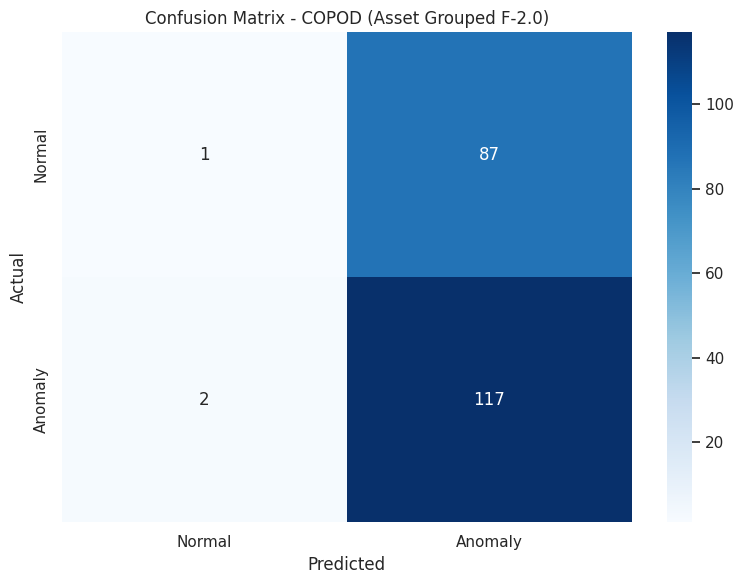

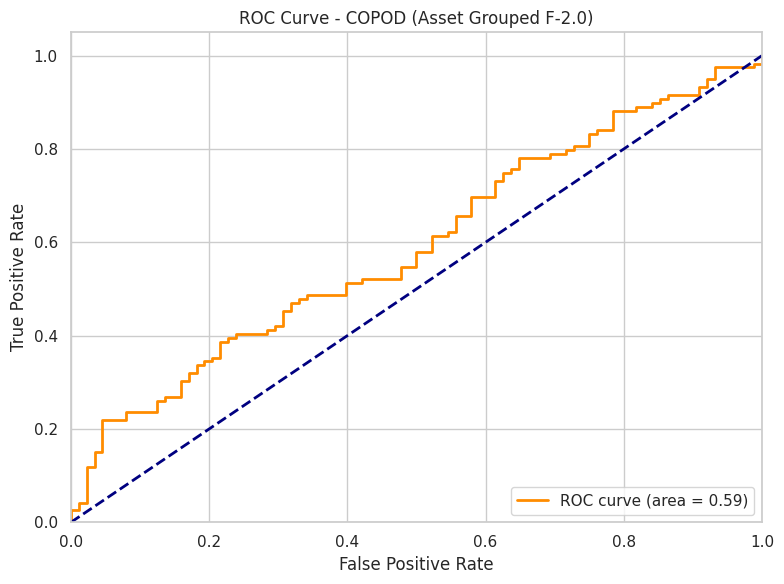

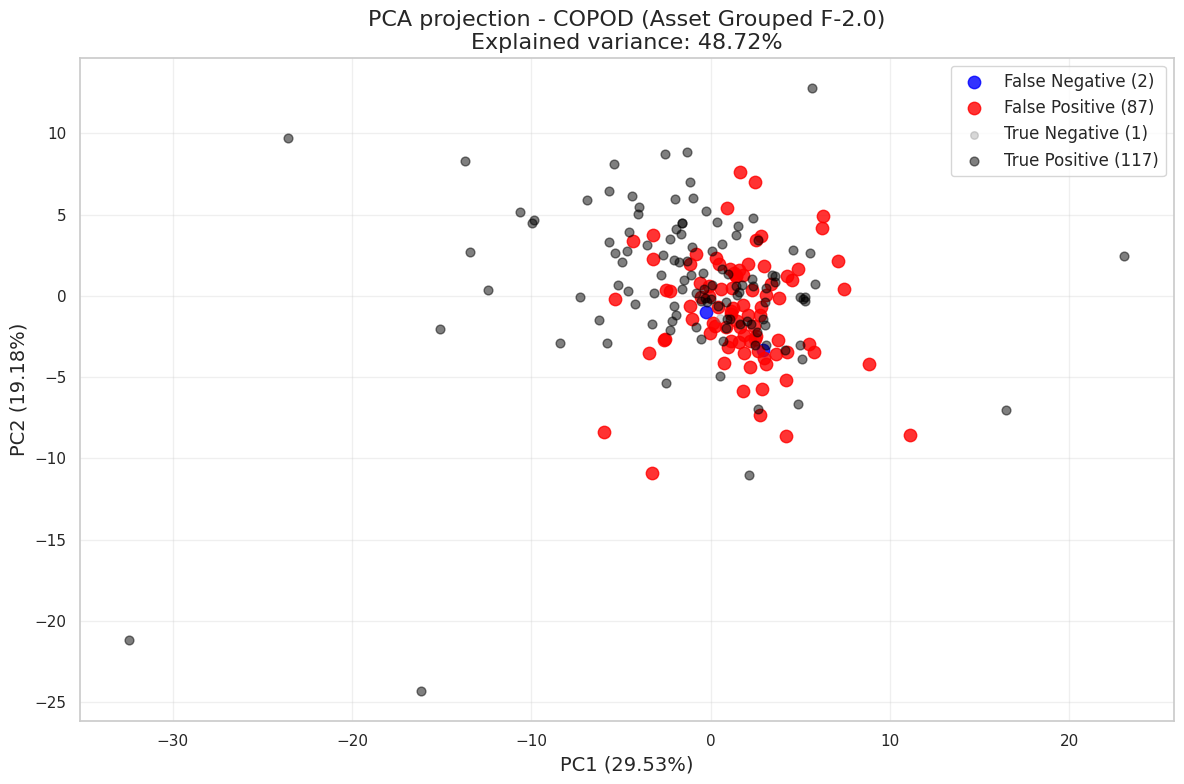

In [ ]:
from pyod.models.copod import COPOD
from sklearn.metrics import fbeta_score

# BETA = 2 means we care twice as much about catching crises (Recall) than false alarms
BETA_PARAM = 2.0

# we define different financial families
groups = {
    'Macro_Volatility': ['VIX', 'DXY', 'ECSURPUS', 'EONIA', 'US0001M', 'USGG3M', 'GBP', 'JPY'],
    'Fixed_Income':     ['GT10', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y',
                         'GTGBP30Y', 'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR',
                         'GTJPY2YR', 'GTJPY30YR', 'USGG2YR', 'USGG30YR'],
    'Credit_Markets':   ['EMUSTRUU', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU',
                         'LUACTRUU', 'LUMSTRUU'],
    'Equities_Comm':    ['MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'BDIY', 'CRY', 'Cl1', 'XAUBGNL']
}

group_indices = {name: [X_df.columns.get_loc(col) for col in cols] for name, cols in groups.items()}

X_train_sub_cv = []
X_train_sub_test = []

for name, indices in group_indices.items():
    sub_model = COPOD(contamination=0.1)
    sub_model.fit(X_train_scaled[:, indices])

    X_train_sub_cv.append(sub_model.decision_function(X_cv_scaled[:, indices]))
    X_train_sub_test.append(sub_model.decision_function(X_test_scaled[:, indices]))

X_cv_meta = np.column_stack(X_train_sub_cv)
X_test_meta = np.column_stack(X_train_sub_test)

copod_model = COPOD(contamination=0.1)
copod_model.fit(X_cv_meta)

cv_scores = copod_model.decision_function(X_cv_meta)

best_fbeta = -1
optimal_threshold = None

threshold_candidates = np.linspace(cv_scores.min(), cv_scores.max(), 200)

for candidate in threshold_candidates:
    cv_preds_candidate = (cv_scores > candidate).astype(int)
    current_fbeta = fbeta_score(y_cross_val, cv_preds_candidate, beta=BETA_PARAM)

    if current_fbeta > best_fbeta:
        best_fbeta = current_fbeta
        optimal_threshold = candidate

print(f"Optimal CV Threshold: {optimal_threshold:.4f}")
print(f"Best CV F-{BETA_PARAM} Score: {best_fbeta:.4f}")

copod_score = copod_model.decision_function(X_test_meta)
copod_pred = (copod_score > optimal_threshold).astype(int)

copod_metrics = evaluate_model(y_test, copod_pred, copod_score, f"COPOD (Asset Grouped F-{BETA_PARAM})")
visualize_pca(X_test_scaled, y_test, copod_pred, f"COPOD (Asset Grouped F-{BETA_PARAM})")


The following block establishes an operational traffic-light routing architecture designed to filter out the high volume of false alarms generated by the raw F2.0​ optimization step. By utilizing a dual-threshold setup calibrated on the validation set, continuous outlier scores are converted into actionable, discrete risk commands:



*   RED ALERT: Triggered by an aggressive statistical threshold corresponding to the 85th percentile of validation scores, capturing severe systemic shocks that justify immediate, high-cost portfolio hedging.


*   AMBER WARNING: Defined by the baseline F2.0​ threshold, acting as an operational buffer zone to capture lower-intensity abnormalities.


*   GREEN REGIME: Normal market operations where scores fall below the warning criteria.

    

This tiered system successfully preserves a high tail sensitivity (capturing 117 out of 119 crises) while neutralizing operational friction. It achieves this by filtering 80 out of the 87 raw false anomalies into the zero-cost AMBER WARNING monitoring zone, ensuring that trading desk capital is not unnecessarily wasted on false alerts.

In [ ]:
cv_scores = copod_model.decision_function(X_cv_meta)
test_scores = copod_model.decision_function(X_test_meta)

amber_statistical_threshold = optimal_threshold

red_statistical_threshold = np.percentile(cv_scores, 85)

print(f"Operational Calibration Gates Complete:")
print(f" -> Amber Warning Gate (F-2.0 Optimized) : {amber_statistical_threshold:.4f}")
print(f" -> Red Alert Gate (85th Percentile)     : {red_statistical_threshold:.4f}")

final_routing = []

for i in range(len(test_scores)):
    score = test_scores[i]

    if score > red_statistical_threshold:
        final_routing.append("RED ALERT (Deploy Portfolio Hedges)")
    elif score > amber_statistical_threshold:
        final_routing.append("AMBER WARNING (Monitor Positions)")
    else:
        final_routing.append("GREEN (Normal Regime)")

operations_df = pd.DataFrame({
    'Actual_Crisis_Label': y_test,
    'Operational_Routing': final_routing
})

print("\n" + "-" * 40)
print("RISK OPERATIONS ACCOUNTABILITY MATRIX")
print("-" * 40)
print(operations_df['Operational_Routing'].value_counts())

true_crises_red = operations_df[(operations_df['Actual_Crisis_Label'] == 1) &
                                 (operations_df['Operational_Routing'] == "RED ALERT (Deploy Portfolio Hedges)")].shape[0]

true_crises_amber = operations_df[(operations_df['Actual_Crisis_Label'] == 1) &
                                   (operations_df['Operational_Routing'] == "AMBER WARNING (Monitor Positions)")].shape[0]

true_crises_missed = operations_df[(operations_df['Actual_Crisis_Label'] == 1) &
                                    (operations_df['Operational_Routing'] == "GREEN (Normal Regime)")].shape[0]

false_alarms_defused = operations_df[(operations_df['Actual_Crisis_Label'] == 0) &
                                     (operations_df['Operational_Routing'] == "AMBER WARNING (Monitor Positions)")].shape[0]

total_f2_false_alarms = np.sum((test_scores > optimal_threshold) & (y_test == 0))

print(f"True Crises in RED ALERT Zone:     {true_crises_red}")
print(f"True Crises in AMBER WARNING Zone: {true_crises_amber}")
print(f"True Crises Completely Missed:      {true_crises_missed}")
print(f"False Alarms Successfully Defused:  {false_alarms_defused} / {total_f2_false_alarms}")
#Total Caught Crises = RED ALERT + AMBER WARNING

Operational Calibration Gates Complete:
 -> Amber Warning Gate (F-2.0 Optimized) : 3.0022
 -> Red Alert Gate (85th Percentile)     : 6.8410

----------------------------------------
RISK OPERATIONS ACCOUNTABILITY MATRIX
----------------------------------------
Operational_Routing
AMBER WARNING (Monitor Positions)      169
RED ALERT (Deploy Portfolio Hedges)     35
GREEN (Normal Regime)                    3
Name: count, dtype: int64
True Crises in RED ALERT Zone:     28
True Crises in AMBER WARNING Zone: 89
True Crises Completely Missed:      2
False Alarms Successfully Defused:  80 / 87
